In [394]:
import numpy as np
import math
import heapq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

In [395]:
#Funcion mapa, genera todos los agentes y atributos del grid
#Generamos la matrix de bloques MxM, con matrices de bloque NxN
#Longitud_Bloques = Longitud de columnas de las matrices de bloque NxN
#Natural = Solo cuadrados natural**2 donde natural:{n∣n⊂Z} 
def mapa(natural,Longitud_Bloques):
    
    Numero_Bloques= natural**2 #Numero de Bloques en la matriz de bloques

    Dimension_Matriz= natural*Longitud_Bloques #Dimension de la Matrix MxM del grid

    #Numero de Indices
    Index=Dimension_Matriz**2 

    #Generamos los indices de la Matriz MxM
    Matriz=np.arange(Index + 1)
    Matriz = Matriz[1:]

    #Generaremos el Tiempo por Indice
    Tiempos=np.random.randint(0,9,Index)
    Tiempos[0]=1
    Tiempos[-1]=1

    #Generamos la Dificultad por Indice
    Dificultad=np.random.randint(0,9,Index)
    Dificultad[0]=1
    Dificultad[-1]=1

    #Generamos las esquinas inferiores
    Esquinas_Inferiores = []
    
    for i in range(Numero_Bloques):
        row = (i // natural) * Longitud_Bloques
        col = (i % natural) * Longitud_Bloques
        index = row * (natural * Longitud_Bloques) + col + 1 
        Esquinas_Inferiores.append(index)
    
    #Generamos las esquinas superiores
    Esquinas_Superiores = []

    for i in range(Numero_Bloques):
        row = (i // natural) * Longitud_Bloques + Longitud_Bloques - 1
        col = (i % natural) * Longitud_Bloques + Longitud_Bloques - 1
        index = row * (natural * Longitud_Bloques) + col + 1  
        Esquinas_Superiores.append(index)   
    
    #Hacemos nuestra lista de valores excluidos
    valores_excluidos = np.array(Esquinas_Inferiores + Esquinas_Superiores)

    #Generamos la matriz de costos
    Costo=Tiempos+Dificultad #Define aqui la Funcion de Costo dependiendo de F(Tiempo,Dificultad) | F: R_2 -> R
    for i in valores_excluidos:
        Costo[i-1] = 0


    #Generamos la cantidad de deliveries que queremos y Generamos nuestra lista de deliveries
    random_length = round(np.log2(np.random.randint(2, (Index/3))))
  
    choices = np.setdiff1d(Matriz[1:-1], valores_excluidos)

    deliveries = np.random.choice(choices, random_length, replace=False)
    

    #Generamos nuestro numero de delivery drivers y asignamos una lista de deliveries
    drivers=np.random.randint(1,random_length)

    np.random.shuffle(deliveries)

    rutas=np.array_split(deliveries, drivers)



    #Generamos lista de deliveries, desde el punto de partida mas cercano
    for idx, ruta in enumerate(rutas):
        Primer_Delivery = ruta[0]
        first_row = (Primer_Delivery - 1) // Dimension_Matriz
        first_col = (Primer_Delivery - 1) % Dimension_Matriz
    
        def euclidean_distance(index):
            row = (index - 1) // Dimension_Matriz
            col = (index - 1) % Dimension_Matriz
            return np.sqrt((row - first_row) ** 2 + (col - first_col) ** 2)

        # Use Esquinas_Inferiores 
        closest_corner = min(Esquinas_Inferiores, key=euclidean_distance)
    
        # Actualizar la ruta en rutas
        rutas[idx] =np.insert(ruta, 0, closest_corner)


    #Generamos lista de deliveries, desde el ultimo delivery
    for idx, ruta in enumerate(rutas):
        Primer_Delivery = ruta[-1]
        last_row = (Primer_Delivery - 1) // Dimension_Matriz
        last_col = (Primer_Delivery - 1) % Dimension_Matriz

        def euclidean_distance(index):
            row = (index - 1) // Dimension_Matriz
            col = (index - 1) % Dimension_Matriz
            return np.sqrt((row - last_row) ** 2 + (col - last_col) ** 2)

        closest_corner = min(Esquinas_Superiores, key=euclidean_distance)

        
        rutas[idx] = np.append(ruta, closest_corner)


    #Generamos Movimientos Validos dada una posicion 
    movimientos_validos = {
    1: (2, Dimension_Matriz + 1, Dimension_Matriz + 2),
    Dimension_Matriz: (Dimension_Matriz - 1, 2 * Dimension_Matriz, 2 * Dimension_Matriz - 1),
    Index: (Index - 1, Index - Dimension_Matriz, Index - Dimension_Matriz - 1),
    Index - Dimension_Matriz + 1: (Index - Dimension_Matriz + 2, Index - 2 * Dimension_Matriz + 1, Index - 2 * Dimension_Matriz + 2)}

    movimientos_validos1 = dict((n, (n + 1, n - 1,n+Dimension_Matriz,n+(Dimension_Matriz+1),n+(Dimension_Matriz-1),n-Dimension_Matriz,n-(Dimension_Matriz+1),n-(Dimension_Matriz-1))) for n in Matriz if (n > Dimension_Matriz and n % Dimension_Matriz != 0 and n% Dimension_Matriz-1 !=0 and n<(Index-Dimension_Matriz)))
    movimientos_validos2 = dict((n, (n + 1, n - 1,n+Dimension_Matriz,n+Dimension_Matriz+1,n+Dimension_Matriz-1)) for n in Matriz if (n>1 and n<Dimension_Matriz))
    movimientos_validos3 = dict((n, (n + 1, n - 1,n-Dimension_Matriz,n-Dimension_Matriz+1,n-Dimension_Matriz-1)) for n in Matriz if (n>Index-Dimension_Matriz+1 and n<Index))
    movimientos_validos4 = dict((n, (n + 1, n - Dimension_Matriz, n - Dimension_Matriz + 1, n + Dimension_Matriz, n + Dimension_Matriz + 1)) for n in Matriz if (n > 1 and n % (Dimension_Matriz) == 1 and n < (Index - Dimension_Matriz + 1)))
    movimientos_validos5 = dict((n, (n - 1,n-Dimension_Matriz,n-Dimension_Matriz-1,n+Dimension_Matriz, n+Dimension_Matriz-1)) for n in Matriz if (n>Dimension_Matriz and n %(Dimension_Matriz)==0 and n<Index))
    
    #Movimientos validos finales
    movimientos_validos_f = {**movimientos_validos, **movimientos_validos1,**movimientos_validos2,**movimientos_validos3,**movimientos_validos4,**movimientos_validos5}



    return Matriz, Tiempos, Dificultad, deliveries, Costo,movimientos_validos_f, rutas, Esquinas_Inferiores,closest_corner,drivers,Dimension_Matriz

#Llamamos a la funcion una vez para crear el grid
Matriz, Tiempos, Dificultad, deliveries, Costo, movimientos_validos4, rutas, corners,closest_corner,drivers,Dimension_Matriz =mapa(4,200)


In [396]:
def heuristic(point_a, point_b):
    return abs(point_a - point_b)


def a_star(start, goal, valid_moves, cost_map):
    open_list = []
    heapq.heappush(open_list, (0 + heuristic(start, goal), 0, start))
    g_scores = {start: 0}
    came_from = {}
    
    while open_list:
        _, current_g, current_node = heapq.heappop(open_list)
        
        if current_node == goal:
            path = []
            while current_node in came_from:
                path.append(current_node)
                current_node = came_from[current_node]
            path.append(start)
            path.reverse()
            return path

        for neighbor in valid_moves[current_node]:
            tentative_g_score = current_g + cost_map[neighbor-1]
            
            if neighbor not in g_scores or tentative_g_score < g_scores[neighbor]:
                g_scores[neighbor] = tentative_g_score
                heapq.heappush(open_list, (tentative_g_score + heuristic(neighbor, goal), tentative_g_score, neighbor))
                came_from[neighbor] = current_node
    
    return None  

def multi_agent_astar(routes, valid_moves, cost_map):
    agent_paths = {}
    agent_costs = {}
    total_cost = 0
    
    for agent_id, route in enumerate(routes):
        path = []
        path_cost = 0
        for i in range(len(route) - 1):
            sub_path = a_star(route[i], route[i+1], valid_moves, cost_map)
            if sub_path:
                path.extend(sub_path[:-1])  
                path_cost += sum(cost_map[node-1] for node in sub_path)
        agent_paths[agent_id] = path + [route[-1]]  
        agent_costs[agent_id] = path_cost
        total_cost += path_cost
        
    return agent_paths, agent_costs, total_cost


agent_paths, agent_costs, total_cost = multi_agent_astar(rutas, movimientos_validos4, Costo.tolist())




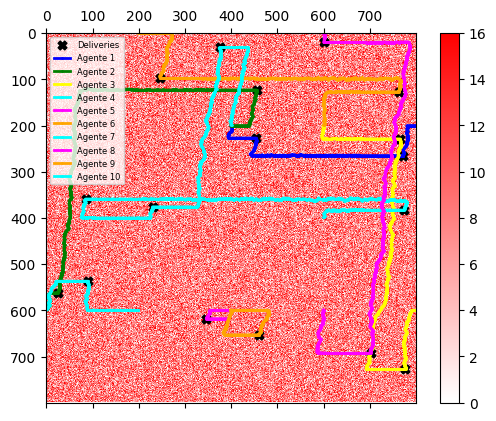

In [397]:
# Transforma la lista Costo en la disposición de matriz deseada
reshaped_costo = np.array(Costo).reshape(Dimension_Matriz, Dimension_Matriz)
transformed_cost_matrix = np.column_stack([reshaped_costo[:,i][::-1] for i in range(reshaped_costo.shape[1])])

#Las entregas son una lista de índices que representan los puntos de entrega
delivery_x_vals, delivery_y_vals = zip(*[((node-1) % Dimension_Matriz, Dimension_Matriz - 1 - (node-1) // Dimension_Matriz) for node in deliveries])

# Crear los objetos figura y eje
fig, ax = plt.subplots()

# Trazar la matriz con la coloración de gradiente basado en la lista de Costo
cmap = mcolors.LinearSegmentedColormap.from_list("costo_gradiente", ["white", "red"])
norm = plt.Normalize(min(Costo), max(Costo))
im = ax.matshow(transformed_cost_matrix, cmap=cmap, norm=norm)
plt.colorbar(im)

#Las Locaciones de las deliveries 
ax.scatter(delivery_x_vals, delivery_y_vals, color='black', label='Deliveries', s=40, marker='X')

# Ploteamos
colors = ['blue', 'green', 'yellow'] + ['cyan', 'magenta', 'orange'] * (len(agent_paths) // 3)  #Colores para los agentes que sean necesarios
for idx, path in enumerate(agent_paths.values()):
    x_vals, y_vals = zip(*[((node-1) % Dimension_Matriz, Dimension_Matriz - 1 - (node-1) // Dimension_Matriz) for node in path])
    ax.plot(x_vals, y_vals, color=colors[idx], label=f'Agente {idx+1}', marker='o', markersize=1, linewidth=2)

ax.legend(fontsize=6)
plt.show()



